Text(0, 0.5, 'Line width Γ, μHz')

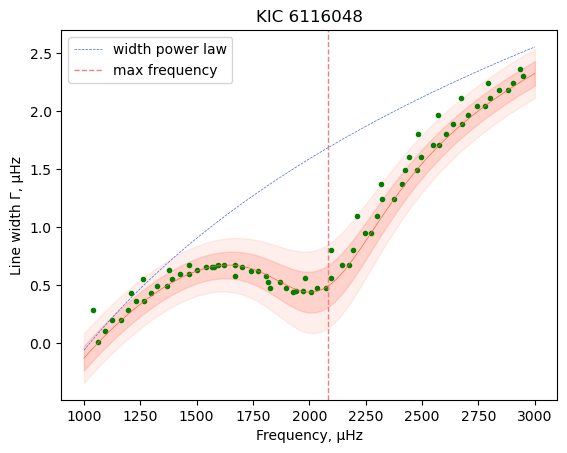

In [46]:
import astropy
import numpy as np
from pathlib import Path
from astropy.nddata import CCDData
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
import glob


mass_star = 1.06
r_star = 1.239
teff_star = 6056
nu_max_sun_uHz = 3090.0
teff_sun_K = 5777.0
max_rms_amplitude_sun = 2.1
delta_nu_sun = 135.1
epsilon = 1.55
    
def calc_maximum_rms_amplitude_radial(mass_star, teff_star):
    luminosity_ratio = (r_star**2) * (teff_star / teff_sun_K) ** 4
    power = -0.093
    t_red_star = 8907*(luminosity_ratio**power)
    delta_t = 1250
    dwarf_suppression_beta = 1 - np.exp((teff_star - t_red_star)/(delta_t))

    max_rms_amplitude_star = max_rms_amplitude_sun * dwarf_suppression_beta * luminosity_ratio *(mass_star**-1) * ((teff_star / teff_sun_K) ** (-2))   
    
    return max_rms_amplitude_star


l = np.linspace(0,3,4)
n = np.linspace(0,30,31)
V = [1, 1.505, 0.620, 0.075]

    
def calc_nl_rms_amplitude_radial(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    #print(nu_max)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    
    #nu_nl.append(delta_nu * (n + (l/2) + epsilon))
    
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    envelope_FWHM = 0.66 * (nu_max ** 0.88)
    
    if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
                
    width_envelope = envelope_FWHM / (2 * np.sqrt(2*np.log(2)))
        
    nl_rms_ampliude_star = (((calc_maximum_rms_amplitude_radial(mass_star, teff_star) ** 2) * np.exp(-((nu_nl - nu_max)**2)/(2*(width_envelope**2))))**0.5)
    
    return nl_rms_ampliude_star


def width_parameter(mass_star, teff_star, a, b):
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    P = (a*(nu_max/3090)) + b
    return P

alpha = width_parameter(mass_star, teff_star, 2.95, 0.39)
width_alpha = width_parameter(mass_star, teff_star, 3.08, 3.32)
delta_width_dip = width_parameter(mass_star, teff_star, -0.47, 0.62)
W_dip = width_parameter(mass_star, teff_star, 4637, -141)
nu_dip = width_parameter(mass_star, teff_star, 2984, 60)
sigma_alpha = 0.05
sigma_lnGamma_alpha = 0.1
sigma_lnDelta = 0.15
sigma_nu_dip_frac = 0.02
sigma_W_dip_frac = 0.05

def log_width_uncertainty(freq):

    X = (2*np.log(freq/nu_dip)) / (np.log(W_dip/nu_max))
    dip_term = 1/(1 + X**2)

    df_dalpha = np.log(freq/nu_max)
    df_dlnGamma_alpha = 1
    df_dlnDelta = dip_term

    sigma2 = ((df_dalpha**2) * sigma_alpha**2 + sigma_lnGamma_alpha**2 + (df_dlnDelta**2) * sigma_lnDelta**2)

    return np.sqrt(sigma2)

def calc_width_nl(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    Lnwidth = ((alpha * np.log(nu_nl/nu_max)) + np.log(width_alpha)) + (np.log(delta_width_dip)/(1 + (((2 * np.log(nu_nl/nu_dip))/(np.log(W_dip/nu_max)))**2)))
    width_nl = np.exp(Lnwidth)

    return width_nl


def lorentz(freq, centroid, FWHM): 
    #scale parameter is the half-width-half-maximum value of the Lorentz curve
    return ((FWHM/2)**2 / ((freq - centroid)**2 + (FWHM/2)**2))

def calc_power_amplitude(amp,width):
    return (2/np.pi)*((amp**2)/width)

nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
envelope_FWHM = 0.66 * (nu_max ** 0.88)
delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))

if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
#print(envelope_FWHM)

standev_envelope = envelope_FWHM / (2*np.sqrt(2*np.log(2)))
nu_envelope_min = nu_max - (3*standev_envelope)
nu_envelope_max = nu_max + (3*standev_envelope)

n_min = []
n_max = []

for i in l:
    n_min.append(int((nu_envelope_min/delta_nu) - ((i/2) + epsilon)))
    n_max.append(int((nu_envelope_max/delta_nu) - ((i/2) + epsilon)))

nu_modes = {0: [], 1: [], 2: [], 3: []}
width_modes = {0: [], 1: [], 2: [], 3: []}
width_modes_power_law = {0: [], 1: [], 2: [], 3: []}

for j in l:
    
    for i in np.linspace(min(n_min), max(n_max), (max(n_max)-min(n_min))+1):
        #nu_nl = delta_nu * (i + (j/2) + epsilon)
        fit = (0.05200 * delta_nu) + np.random.normal(1.42683, 1.41997)
        # fit = (0.05200 * self.star_delta_nu) + 1.42683
        
        
        if j % 2 == 0:
        
            nu_nl = delta_nu * ( i+(j/2) + epsilon) - fit * j * (j+1)
            
        elif j % 2 == 1:
            nu_nl = delta_nu * ( i+(j/2) + epsilon) - fit * (5/3) * j * (j+1)
        nu_modes[int(j)].append(nu_nl)
    
nu_range = np.linspace(1000,3000,10000)
power_density = np.zeros(len(nu_range))
standev = 0.68
for j in l:
    
    for i in np.linspace(min(n_min), max(n_max), (max(n_max)-min(n_min))+1):
        #nu_nl = delta_nu * (i + (j/2) + epsilon)
        fit = (0.05200 * delta_nu) + np.random.normal(1.42683, 1.41997)
        # fit = (0.05200 * self.star_delta_nu) + 1.42683
        # fit = 3
        
        if j % 2 == 0:
        
            nu_nl = delta_nu * ( i+(j/2) + epsilon) - fit * j * (j+1)
            
        elif j % 2 == 1:
            nu_nl = delta_nu * ( i+(j/2) + epsilon) - fit * (5/3) * j * (j+1)
            # nu_nl = self.star_delta_nu * ( n+(l/2) + self.epsilon) - fit * l * (l+1)
        
        amplitude_nl =V[int(j)] * calc_nl_rms_amplitude_radial(mass_star, teff_star, i, j)
        width_nl = calc_width_nl(mass_star, teff_star, i, j)
        width_modes[int(j)].append(width_nl)

def width_model(freq):
    model = []
    for i in freq:
        Lnwidth = ((alpha * np.log(i/nu_max)) + np.log(width_alpha)) + (np.log(delta_width_dip)/(1 + (((2 * np.log(i/nu_dip))/(np.log(W_dip/nu_max)))**2)))
        width = np.exp(Lnwidth)
        model.append(width)
    return model


def width_power_law(freq):
    power_law = []
    
    for i in freq:
        width_power_law = width_alpha * (i/nu_max)**alpha
        power_law.append(width_power_law)
    return power_law        
    

def width_standev(width_mode):
    top_1_bracket = []
    bottom_1_bracket = []
    top_2_bracket = []
    bottom_2_bracket = []
    
    for i in width_mode:
        top_1_bracket.append((i + (i*0.34)))
        bottom_1_bracket.append((i - (i*0.34)))
        top_2_bracket.append((i + (2*(i*0.34))))
        bottom_2_bracket.append((i - (2*(i*0.34))))
    
    return top_1_bracket, bottom_1_bracket, top_2_bracket, bottom_2_bracket


# 1σ and 2σ bounds
top1, bottom1, top2, bottom2 = width_standev(width_model_vals)

plt.plot(nu_range, np.log(width_power_law(nu_range)), color='royalblue', label='width power law', linestyle='dashed', linewidth=0.5) 
plt.plot(nu_range, np.log(width_model(nu_range)), color='tomato', linewidth=0.5)

log_model = np.log(width_model(nu_range))
sigma_log = log_width_uncertainty(nu_range)

plt.fill_between(nu_range, log_model - sigma_log, log_model + sigma_log, alpha=0.2, color='tomato')
plt.fill_between(nu_range, log_model - 2*sigma_log, log_model + 2*sigma_log, alpha=0.1, color='tomato')

plt.scatter(nu_modes[0], np.log(width_modes[0]), marker='.', color='g')
plt.scatter(nu_modes[1], np.log(width_modes[1]), marker='.', color='g')
plt.scatter(nu_modes[2], np.log(width_modes[2]), marker='.', color='g')
plt.scatter(nu_modes[3], np.log(width_modes[3]), marker='.', color='g')
plt.axvline(nu_max, ls='--', color='lightcoral', label='max frequency', linewidth='1')
plt.title('KIC 6116048')
plt.legend()
plt.xlabel('Frequency, μHz')
plt.ylabel('Line width Γ, μHz')
